# 06c — EnbPI online para todos los modelos

Este notebook aplica **Ensemble Batch Prediction Intervals (EnbPI)** a los cuatro modelos puntuales del proyecto:

- modelo base ingenuo estacional;
- regresión lineal;
- LightGBM;
- CatBoost.

Se plantea como un experimento complementario a los intervalos obtenidos con *split conformal* y CQR. La idea es evaluar EnbPI en una configuración **online simulada**: el bloque de evaluación se recorre en orden temporal y los *conformal scores* se actualizan únicamente cuando el valor real correspondiente ya estaría disponible.

El notebook considera varios esquemas de `BlockBootstrap`, inspirados en el enfoque del TFG de referencia:

- bloques anuales aproximados;
- bloques trimestrales aproximados;
- bloques mensuales aproximados.

Por defecto, el notebook usa `train + calibration` como histórico de ajuste de EnbPI y evalúa sobre `validation`. El conjunto `test` queda protegido.

## 1. Importaciones y configuración general

In [1]:
from __future__ import annotations

import inspect
import json
import warnings
from pathlib import Path
from typing import Dict, List, Any

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.lines import Line2D
from IPython.display import display

from sklearn.base import BaseEstimator, RegressorMixin, clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

try:
    from mapie.regression import TimeSeriesRegressor
except ImportError:
    try:
        from mapie.regression import MapieTimeSeriesRegressor as TimeSeriesRegressor
    except ImportError as exc:
        raise ImportError(
            "No se ha podido importar TimeSeriesRegressor ni MapieTimeSeriesRegressor. "
            "Revisa la versión de MAPIE instalada."
        ) from exc

try:
    from mapie.subsample import BlockBootstrap
except ImportError as exc:
    raise ImportError(
        "Este notebook requiere BlockBootstrap de MAPIE para aplicar EnbPI."
    ) from exc

pd.set_option("display.max_columns", 160)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 180)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

warnings.filterwarnings("ignore")

In [ ]:
def find_project_root(start: Path | None = None) -> Path:
    """Busca la raíz del proyecto partiendo del directorio actual."""
    current = Path.cwd() if start is None else start.resolve()

    for candidate in [current, *current.parents]:
        if (candidate / "data").exists() and (candidate / "reports").exists():
            return candidate

    raise FileNotFoundError(
        "No se pudo localizar la raíz del proyecto. Debe ejecutarse el notebook "
        "desde la raíz del repositorio o desde la carpeta notebooks/."
    )


PROJECT_ROOT = find_project_root()

MODELING_DATA_DIR = PROJECT_ROOT / "data" / "modeling"
REPORTS_TABLES_DIR = PROJECT_ROOT / "reports" / "tables"
REPORTS_FIGURES_DIR = PROJECT_ROOT / "reports" / "figures"
REPORTS_INTERVALS_DIR = PROJECT_ROOT / "reports" / "intervals"
MODELS_ROOT_DIR = PROJECT_ROOT / "models"
ENBPI_MODELS_DIR = MODELS_ROOT_DIR / "enbpi_online"

for directory in [
    REPORTS_TABLES_DIR,
    REPORTS_FIGURES_DIR,
    REPORTS_INTERVALS_DIR,
    ENBPI_MODELS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

FEATURE_COLUMNS_PATH = MODELING_DATA_DIR / "feature_columns.json"

HORIZONS: List[int] = [1, 4, 12, 24]

# EnbPI no necesita reservar un conjunto de calibración separado.
# Para seleccionar la configuración sobre validación, se aprovecha todo el histórico anterior.
ENBPI_TRAIN_SPLITS: List[str] = ["train", "calibration"]
EVALUATION_SPLIT = "validation"
ALLOW_TEST_EVALUATION = False

ALPHA = 0.20
CONFIDENCE_LEVEL = 1 - ALPHA
NOMINAL_COVERAGE = CONFIDENCE_LEVEL

# ------------------------------------------------------------------
# Configuraciones de BlockBootstrap
# ------------------------------------------------------------------
# Si el histórico de entrenamiento usado por EnbPI cubre aproximadamente 2020-2023,
# estas configuraciones son análogas a bloques anuales, trimestrales y mensuales.
# El número de resamplings se mantiene moderado para que el experimento sea viable.
N_RESAMPLINGS = 10
BLOCK_BOOTSTRAP_CONFIGS: list[dict[str, Any]] = [
    {
        "config_id": "annual_approx",
        "description": "Bloques anuales aproximados",
        "n_blocks": 4,
    },
    {
        "config_id": "quarterly_approx",
        "description": "Bloques trimestrales aproximados",
        "n_blocks": 16,
    },
    {
        "config_id": "monthly_approx",
        "description": "Bloques mensuales aproximados",
        "n_blocks": 48,
    },
]

# Si necesitas una primera prueba más rápida, deja solo una configuración, por ejemplo:
# BLOCK_BOOTSTRAP_CONFIGS = [BLOCK_BOOTSTRAP_CONFIGS[1]]

RUN_OFFLINE_REFERENCE = True
RUN_ONLINE_UPDATE = True
ONLINE_MODE_NAME = "online"
OFFLINE_MODE_NAME = "offline"

OVERLAPPING_BLOCKS = False
RANDOM_STATE = 42
N_JOBS = -1
AGG_FUNCTION = "mean"
OPTIMIZE_BETA = False

# Muy importante para h > 1: no se actualizan scores con objetivos que todavía
# no estarían observados en el instante de origen de la predicción actual.
RESPECT_TARGET_DELAY_IN_ONLINE_UPDATE = True

# Si alguna versión de MAPIE/estimador no acepta valores ausentes en X, activa esto.
FORCE_MEDIAN_IMPUTATION_FOR_MAPIE = False

SAVE_FITTED_MAPIE_OBJECTS = False
BASELINE_FEATURE = "o3_prev_day_same_hour"

if EVALUATION_SPLIT == "test" and not ALLOW_TEST_EVALUATION:
    raise ValueError(
        "Este notebook está configurado para no evaluar sobre test. "
        "Si realmente quieres hacerlo, cambia ALLOW_TEST_EVALUATION=True."
    )

print(f"Raíz del proyecto: {PROJECT_ROOT}")
print(f"Datasets de modelado: {MODELING_DATA_DIR}")
print(f"Modelos puntuales: {MODELS_ROOT_DIR}")
print(f"Intervalos EnbPI: {REPORTS_INTERVALS_DIR}")
print(f"Train splits EnbPI: {ENBPI_TRAIN_SPLITS}")
print(f"Split de evaluación: {EVALUATION_SPLIT}")
print(f"Cobertura nominal: {NOMINAL_COVERAGE:.0%}")
print("Configuraciones EnbPI:")
for cfg in BLOCK_BOOTSTRAP_CONFIGS:
    print("  -", cfg)

Raíz del proyecto: c:\trabajo_github
Datasets de modelado: c:\trabajo_github\data\modeling
Modelos puntuales: c:\trabajo_github\models
Intervalos EnbPI: c:\trabajo_github\reports\intervals
Train splits EnbPI: ['train', 'calibration']
Split de evaluación: validation
Cobertura nominal: 90%
Configuraciones EnbPI:
  - {'config_id': 'annual_approx', 'description': 'Bloques anuales aproximados', 'n_blocks': 4}
  - {'config_id': 'quarterly_approx', 'description': 'Bloques trimestrales aproximados', 'n_blocks': 16}
  - {'config_id': 'monthly_approx', 'description': 'Bloques mensuales aproximados', 'n_blocks': 48}


In [3]:
MODEL_REGISTRY: Dict[str, Dict[str, object]] = {
    "baseline_seasonal_naive": {
        "display_name": "Modelo base ingenuo estacional",
        "short_name": "Baseline",
        "label": "Baseline + EnbPI online",
        "color": "tab:blue",
        "model_dir": None,
        "model_file_pattern": None,
        "interval_prefix": "enbpi_online_baseline_seasonal_naive",
    },
    "linear_regression": {
        "display_name": "Regresión lineal",
        "short_name": "Reg. lineal",
        "label": "Regresión lineal + EnbPI online",
        "color": "tab:green",
        "model_dir": MODELS_ROOT_DIR / "linear_regression",
        "model_file_pattern": "linear_regression_h{horizon:02d}.joblib",
        "interval_prefix": "enbpi_online_linear_regression",
    },
    "lightgbm": {
        "display_name": "LightGBM",
        "short_name": "LightGBM",
        "label": "LightGBM + EnbPI online",
        "color": "tab:red",
        "model_dir": MODELS_ROOT_DIR / "lightgbm",
        "model_file_pattern": "lightgbm_h{horizon:02d}.joblib",
        "interval_prefix": "enbpi_online_lightgbm",
    },
    "catboost": {
        "display_name": "CatBoost",
        "short_name": "CatBoost",
        "label": "CatBoost + EnbPI online",
        "color": "tab:purple",
        "model_dir": MODELS_ROOT_DIR / "catboost",
        "model_file_pattern": "catboost_h{horizon:02d}.joblib",
        "interval_prefix": "enbpi_online_catboost",
    },
}

MODEL_ORDER = list(MODEL_REGISTRY.keys())
MODEL_ORDER

['baseline_seasonal_naive', 'linear_regression', 'lightgbm', 'catboost']

## 2. Carga de variables predictoras y datasets por horizonte

In [4]:
if not FEATURE_COLUMNS_PATH.exists():
    raise FileNotFoundError(
        "No se ha encontrado data/modeling/feature_columns.json. "
        "Ejecuta antes 02_modeling_dataset_features.ipynb."
    )

feature_payload = json.loads(FEATURE_COLUMNS_PATH.read_text(encoding="utf-8"))
feature_columns_by_horizon: Dict[str, List[str]] = feature_payload.get("feature_columns_by_horizon", {})
default_feature_columns: List[str] = feature_payload.get("feature_columns", [])

if not feature_columns_by_horizon and not default_feature_columns:
    raise ValueError("feature_columns.json no contiene variables predictoras.")

feature_summary_rows = []
for horizon in HORIZONS:
    cols = feature_columns_by_horizon.get(str(horizon), default_feature_columns)
    feature_summary_rows.append({"horizon": horizon, "n_features": len(cols), "features": cols})

feature_summary_df = pd.DataFrame(feature_summary_rows)
display(feature_summary_df[["horizon", "n_features"]])

,horizon,n_features
0,1,21
1,4,21
2,12,20
3,24,20


In [5]:
def load_modeling_dataset(horizon: int) -> pd.DataFrame:
    file_path = MODELING_DATA_DIR / f"modeling_h{horizon:02d}.parquet"

    if not file_path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {file_path}. Ejecuta antes 02_modeling_dataset_features."
        )

    df = pd.read_parquet(file_path)
    df["origin_timestamp"] = pd.to_datetime(df["origin_timestamp"])
    df["target_timestamp"] = pd.to_datetime(df["target_timestamp"])
    df = df.sort_values(["target_timestamp", "origin_timestamp"]).reset_index(drop=True)
    return df


datasets_by_horizon: Dict[int, pd.DataFrame] = {
    horizon: load_modeling_dataset(horizon)
    for horizon in HORIZONS
}

dataset_overview_rows = []
for horizon, df in datasets_by_horizon.items():
    dataset_overview_rows.append(
        {
            "horizon": horizon,
            "n_rows": len(df),
            "splits": sorted(df["split"].dropna().unique().tolist()),
            "target_min": df["target_timestamp"].min(),
            "target_max": df["target_timestamp"].max(),
            "missing_y": int(df["y"].isna().sum()),
        }
    )

dataset_overview_df = pd.DataFrame(dataset_overview_rows)
display(dataset_overview_df)

,horizon,n_rows,splits,target_min,target_max,missing_y
0,1,50941,"[calibration, test, train, validation]",2020-01-01 01:00:00,2025-12-31 23:00:00,0
1,4,50938,"[calibration, test, train, validation]",2020-01-01 04:00:00,2025-12-31 23:00:00,0
2,12,50930,"[calibration, test, train, validation]",2020-01-01 12:00:00,2025-12-31 23:00:00,0
3,24,50918,"[calibration, test, train, validation]",2020-01-02 00:00:00,2025-12-31 23:00:00,0


## 3. Funciones auxiliares

In [6]:
class SeasonalNaiveEstimator(BaseEstimator, RegressorMixin):
    """Estimador sklearn para el modelo base ingenuo estacional.

    Predice directamente la columna `o3_prev_day_same_hour`, que coincide con la
    regla de persistencia diaria del modelo base.
    """

    def __init__(self, feature_name: str = BASELINE_FEATURE):
        self.feature_name = feature_name

    def fit(self, X, y=None):
        if self.feature_name not in X.columns:
            raise ValueError(f"La columna {self.feature_name!r} no está disponible en X.")
        self.is_fitted_ = True
        self.n_features_in_ = X.shape[1]
        return self

    def predict(self, X):
        if self.feature_name not in X.columns:
            raise ValueError(f"La columna {self.feature_name!r} no está disponible en X.")
        return X[self.feature_name].to_numpy(dtype=float)


def interval_score(
    y_true: pd.Series | np.ndarray,
    lower: pd.Series | np.ndarray,
    upper: pd.Series | np.ndarray,
    alpha: float,
) -> np.ndarray:
    """Calcula el interval score para intervalos centrales."""
    y = np.asarray(y_true, dtype=float)
    l = np.asarray(lower, dtype=float)
    u = np.asarray(upper, dtype=float)

    width = u - l
    lower_penalty = (2 / alpha) * (l - y) * (y < l)
    upper_penalty = (2 / alpha) * (y - u) * (y > u)

    return width + lower_penalty + upper_penalty


def enforce_interval_order(lower: np.ndarray, upper: np.ndarray) -> tuple[np.ndarray, np.ndarray, int]:
    """Garantiza lower <= upper."""
    lower_arr = np.asarray(lower, dtype=float)
    upper_arr = np.asarray(upper, dtype=float)
    crossed = lower_arr > upper_arr
    return np.minimum(lower_arr, upper_arr), np.maximum(lower_arr, upper_arr), int(crossed.sum())


def extract_mapie_output(y_pred, y_interval) -> tuple[np.ndarray, np.ndarray, np.ndarray]:
    """Extrae predicción central y límites de una salida MAPIE."""
    y_pred_array = np.asarray(y_pred, dtype=float).reshape(-1)
    interval_array = np.asarray(y_interval, dtype=float)

    if interval_array.ndim == 2 and interval_array.shape[1] == 2:
        lower = interval_array[:, 0]
        upper = interval_array[:, 1]
    elif interval_array.ndim == 3 and interval_array.shape[1] == 2:
        lower = interval_array[:, 0, 0]
        upper = interval_array[:, 1, 0]
    elif interval_array.ndim == 3 and interval_array.shape[2] == 2:
        lower = interval_array[:, 0, 0]
        upper = interval_array[:, 0, 1]
    else:
        squeezed = np.squeeze(interval_array)
        if squeezed.ndim == 2 and squeezed.shape[1] == 2:
            lower = squeezed[:, 0]
            upper = squeezed[:, 1]
        else:
            raise ValueError(f"Formato inesperado de y_interval: shape={interval_array.shape}")

    lower, upper, _ = enforce_interval_order(lower, upper)
    return y_pred_array, lower, upper


def maybe_wrap_with_imputer(estimator):
    """Envuelve un estimador con imputación de mediana si se solicita explícitamente."""
    if not FORCE_MEDIAN_IMPUTATION_FOR_MAPIE:
        return estimator

    return Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("model", estimator),
        ]
    )


def get_feature_columns(model_id: str, horizon: int) -> list[str]:
    if model_id == "baseline_seasonal_naive":
        return [BASELINE_FEATURE]
    return feature_columns_by_horizon.get(str(horizon), default_feature_columns)


def load_base_estimator(model_id: str, horizon: int):
    """Carga el estimador puntual usado como base de EnbPI."""
    if model_id == "baseline_seasonal_naive":
        return SeasonalNaiveEstimator(feature_name=BASELINE_FEATURE)

    meta = MODEL_REGISTRY[model_id]
    model_dir = meta["model_dir"]
    model_file_pattern = meta["model_file_pattern"]
    model_path = model_dir / model_file_pattern.format(horizon=horizon)

    if not model_path.exists():
        raise FileNotFoundError(
            f"No se ha encontrado {model_path}. Ejecuta antes 04a/04b/04c."
        )

    estimator = joblib.load(model_path)

    try:
        estimator = clone(estimator)
    except Exception:
        # Algunos objetos complejos pueden no clonarse bien. MAPIE intentará
        # gestionar el estimador recibido. Si falla, conviene reconstruir el
        # estimador desde sus hiperparámetros.
        pass

    return maybe_wrap_with_imputer(estimator)


def prepare_train_eval_data(
    df: pd.DataFrame,
    feature_columns: list[str],
    model_id: str,
    train_splits: list[str],
    evaluation_split: str,
) -> tuple[pd.DataFrame, pd.Series, pd.DataFrame, pd.Series, pd.DataFrame]:
    """Prepara train y evaluación respetando los splits cronológicos."""
    missing_columns = [col for col in feature_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(f"Faltan columnas predictoras: {missing_columns}")

    train_df = df.loc[df["split"].isin(train_splits)].copy()
    eval_df = df.loc[df["split"] == evaluation_split].copy()

    train_df = train_df.loc[train_df["y"].notna()].copy()
    eval_df = eval_df.loc[eval_df["y"].notna()].copy()

    # El baseline no puede predecir si su retardo diario está ausente.
    if model_id == "baseline_seasonal_naive":
        train_df = train_df.dropna(subset=feature_columns).copy()
        eval_df = eval_df.dropna(subset=feature_columns).copy()

    train_df = train_df.sort_values(["target_timestamp", "origin_timestamp"]).reset_index(drop=True)
    eval_df = eval_df.sort_values(["origin_timestamp", "target_timestamp"]).reset_index(drop=True)

    X_train = train_df[feature_columns].copy()
    y_train = train_df["y"].astype(float).copy()

    X_eval = eval_df[feature_columns].copy()
    y_eval = eval_df["y"].astype(float).copy()

    metadata_columns = ["horizon", "split", "origin_timestamp", "target_timestamp"]
    eval_metadata = eval_df[metadata_columns].copy()

    return X_train, y_train, X_eval, y_eval, eval_metadata

In [7]:
def make_block_bootstrap(n_blocks: int, n_train: int) -> BlockBootstrap:
    """Construye BlockBootstrap con compatibilidad entre versiones de MAPIE."""
    signature = inspect.signature(BlockBootstrap)
    kwargs: dict[str, object] = {}

    if "n_resamplings" in signature.parameters:
        kwargs["n_resamplings"] = N_RESAMPLINGS
    if "n_blocks" in signature.parameters:
        kwargs["n_blocks"] = n_blocks
    elif "length" in signature.parameters:
        # Fallback para versiones que parametrizan por longitud de bloque.
        kwargs["length"] = max(1, int(np.ceil(n_train / n_blocks)))
    if "overlapping" in signature.parameters:
        kwargs["overlapping"] = OVERLAPPING_BLOCKS
    if "random_state" in signature.parameters:
        kwargs["random_state"] = RANDOM_STATE

    return BlockBootstrap(**kwargs)


def build_enbpi_regressor(estimator, n_blocks: int, n_train: int) -> TimeSeriesRegressor:
    """Construye TimeSeriesRegressor de MAPIE para EnbPI."""
    cv_mapie = make_block_bootstrap(n_blocks=n_blocks, n_train=n_train)

    signature = inspect.signature(TimeSeriesRegressor)
    candidate_kwargs = {
        "estimator": estimator,
        "method": "enbpi",
        "cv": cv_mapie,
        "agg_function": AGG_FUNCTION,
        "n_jobs": N_JOBS,
        "random_state": RANDOM_STATE,
    }
    kwargs = {key: value for key, value in candidate_kwargs.items() if key in signature.parameters}

    return TimeSeriesRegressor(**kwargs)


def mapie_predict_interval(
    mapie_model,
    X: pd.DataFrame,
    confidence_level: float,
    ensemble: bool = True,
    optimize_beta: bool = False,
):
    """Llama a predict con compatibilidad entre APIs de MAPIE."""
    signature = inspect.signature(mapie_model.predict)
    kwargs = {}

    if "confidence_level" in signature.parameters:
        kwargs["confidence_level"] = confidence_level
    elif "alpha" in signature.parameters:
        kwargs["alpha"] = 1 - confidence_level

    if "ensemble" in signature.parameters:
        kwargs["ensemble"] = ensemble
    if "optimize_beta" in signature.parameters:
        kwargs["optimize_beta"] = optimize_beta
    if "allow_infinite_bounds" in signature.parameters:
        kwargs["allow_infinite_bounds"] = False

    return mapie_model.predict(X, **kwargs)


def mapie_update(mapie_model, X: pd.DataFrame, y: pd.Series | np.ndarray) -> None:
    """Actualiza scores conformes con compatibilidad entre APIs de MAPIE."""
    if len(X) == 0:
        return

    if hasattr(mapie_model, "update"):
        signature = inspect.signature(mapie_model.update)
        kwargs = {}
        if "ensemble" in signature.parameters:
            kwargs["ensemble"] = True
        if "confidence_level" in signature.parameters:
            kwargs["confidence_level"] = CONFIDENCE_LEVEL
        elif "alpha" in signature.parameters:
            kwargs["alpha"] = ALPHA
        if "optimize_beta" in signature.parameters:
            kwargs["optimize_beta"] = OPTIMIZE_BETA
        mapie_model.update(X, y, **kwargs)
    elif hasattr(mapie_model, "partial_fit"):
        signature = inspect.signature(mapie_model.partial_fit)
        kwargs = {}
        if "ensemble" in signature.parameters:
            kwargs["ensemble"] = True
        if "confidence_level" in signature.parameters:
            kwargs["confidence_level"] = CONFIDENCE_LEVEL
        elif "alpha" in signature.parameters:
            kwargs["alpha"] = ALPHA
        if "optimize_beta" in signature.parameters:
            kwargs["optimize_beta"] = OPTIMIZE_BETA
        mapie_model.partial_fit(X, y, **kwargs)
    else:
        raise AttributeError(
            "El objeto MAPIE no dispone de update ni partial_fit. "
            "No se puede aplicar EnbPI online."
        )


def predict_enbpi_offline(
    mapie_ts: TimeSeriesRegressor,
    X_eval: pd.DataFrame,
    eval_metadata: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    """Predice todo el bloque de evaluación sin actualización online."""
    y_pred, y_pis = mapie_predict_interval(
        mapie_ts,
        X_eval,
        confidence_level=CONFIDENCE_LEVEL,
        ensemble=True,
        optimize_beta=OPTIMIZE_BETA,
    )
    y_pred, lower, upper = extract_mapie_output(y_pred, y_pis)

    diagnostics = eval_metadata.reset_index(drop=True).copy()
    diagnostics["n_scores_updated_before_prediction"] = 0
    diagnostics["n_new_scores_updated_before_prediction"] = 0

    return y_pred, lower, upper, diagnostics


def predict_enbpi_online(
    mapie_ts: TimeSeriesRegressor,
    X_eval: pd.DataFrame,
    y_eval: pd.Series,
    eval_metadata: pd.DataFrame,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, pd.DataFrame]:
    """Predice online evitando fuga temporal en horizontes h > 1.

    Antes de predecir una fila con origin_timestamp = t, solo se actualiza con
    predicciones previas cuyo target_timestamp <= t. Así no se utiliza un valor real
    que todavía no habría ocurrido en el momento de emitir la predicción.
    """
    X_eval = X_eval.reset_index(drop=True)
    y_eval = y_eval.reset_index(drop=True)
    metadata = eval_metadata.reset_index(drop=True).copy()

    n = len(X_eval)
    y_pred_all = np.full(n, np.nan)
    lower_all = np.full(n, np.nan)
    upper_all = np.full(n, np.nan)
    n_scores_updated_before_prediction = np.zeros(n, dtype=int)
    n_new_scores_updated_before_prediction = np.zeros(n, dtype=int)

    already_updated = np.zeros(n, dtype=bool)

    for i in range(n):
        current_origin = metadata.loc[i, "origin_timestamp"]

        if RESPECT_TARGET_DELAY_IN_ONLINE_UPDATE:
            eligible_idx = np.where(
                (~already_updated)
                & (np.arange(n) < i)
                & (metadata["target_timestamp"].to_numpy() <= np.datetime64(current_origin))
            )[0]
        else:
            eligible_idx = np.array([i - 1], dtype=int) if i > 0 and not already_updated[i - 1] else np.array([], dtype=int)

        if len(eligible_idx) > 0:
            mapie_update(
                mapie_ts,
                X_eval.iloc[eligible_idx],
                y_eval.iloc[eligible_idx],
            )
            already_updated[eligible_idx] = True

        n_new_scores_updated_before_prediction[i] = int(len(eligible_idx))
        n_scores_updated_before_prediction[i] = int(already_updated.sum())

        y_pred_i, y_pis_i = mapie_predict_interval(
            mapie_ts,
            X_eval.iloc[[i]],
            confidence_level=CONFIDENCE_LEVEL,
            ensemble=True,
            optimize_beta=OPTIMIZE_BETA,
        )
        y_pred_i, lower_i, upper_i = extract_mapie_output(y_pred_i, y_pis_i)

        y_pred_all[i] = y_pred_i[0]
        lower_all[i] = lower_i[0]
        upper_all[i] = upper_i[0]

    diagnostics = metadata.copy()
    diagnostics["n_scores_updated_before_prediction"] = n_scores_updated_before_prediction
    diagnostics["n_new_scores_updated_before_prediction"] = n_new_scores_updated_before_prediction

    return y_pred_all, lower_all, upper_all, diagnostics


def compute_interval_metrics(interval_df: pd.DataFrame) -> dict[str, float]:
    """Resume cobertura, anchura e interval score."""
    coverage = float(interval_df["covered"].mean())
    return {
        "n_observations": int(len(interval_df)),
        "coverage": coverage,
        "nominal_coverage": NOMINAL_COVERAGE,
        "coverage_abs_error": float(abs(coverage - NOMINAL_COVERAGE)),
        "mean_width": float(interval_df["interval_width"].mean()),
        "median_width": float(interval_df["interval_width"].median()),
        "mean_interval_score": float(interval_df["interval_score"].mean()),
        "median_interval_score": float(interval_df["interval_score"].median()),
        "miss_lower_rate": float(interval_df["miss_lower"].mean()),
        "miss_upper_rate": float(interval_df["miss_upper"].mean()),
    }

In [8]:
def build_interval_frame(
    diagnostics: pd.DataFrame,
    y_true: pd.Series,
    y_pred: np.ndarray,
    lower: np.ndarray,
    upper: np.ndarray,
    model_id: str,
    horizon: int,
    config: dict[str, Any],
    evaluation_mode: str,
    n_crossed: int,
) -> pd.DataFrame:
    """Construye el DataFrame estandarizado de intervalos EnbPI."""
    meta = MODEL_REGISTRY[model_id]

    interval_df = diagnostics.copy().reset_index(drop=True)
    interval_df["model"] = model_id
    interval_df["model_display"] = meta["display_name"]
    interval_df["method"] = f"enbpi_{evaluation_mode}"
    interval_df["method_display"] = "EnbPI online" if evaluation_mode == ONLINE_MODE_NAME else "EnbPI offline"
    interval_df["label"] = f"{meta['display_name']} + {interval_df['method_display'].iloc[0]}"
    interval_df["short_name"] = meta["short_name"]
    interval_df["color"] = meta["color"]
    interval_df["horizon"] = horizon
    interval_df["split"] = EVALUATION_SPLIT

    interval_df["y_true"] = y_true.reset_index(drop=True).to_numpy(dtype=float)
    interval_df["y_pred_reference"] = y_pred
    interval_df["lower"] = lower
    interval_df["upper"] = upper

    interval_df["interval_width"] = interval_df["upper"] - interval_df["lower"]
    interval_df["covered"] = (interval_df["y_true"] >= interval_df["lower"]) & (interval_df["y_true"] <= interval_df["upper"])
    interval_df["miss_lower"] = interval_df["y_true"] < interval_df["lower"]
    interval_df["miss_upper"] = interval_df["y_true"] > interval_df["upper"]
    interval_df["interval_score"] = interval_score(interval_df["y_true"], interval_df["lower"], interval_df["upper"], ALPHA)

    interval_df["alpha"] = ALPHA
    interval_df["nominal_coverage"] = NOMINAL_COVERAGE
    interval_df["confidence_level"] = CONFIDENCE_LEVEL

    interval_df["block_config_id"] = config["config_id"]
    interval_df["block_config_description"] = config["description"]
    interval_df["n_resamplings"] = N_RESAMPLINGS
    interval_df["n_blocks"] = int(config["n_blocks"])
    interval_df["overlapping_blocks"] = OVERLAPPING_BLOCKS
    interval_df["evaluation_mode"] = evaluation_mode
    interval_df["online_step_size"] = 1 if evaluation_mode == ONLINE_MODE_NAME else 0
    interval_df["train_splits"] = "+".join(ENBPI_TRAIN_SPLITS)
    interval_df["respect_target_delay_in_online_update"] = RESPECT_TARGET_DELAY_IN_ONLINE_UPDATE
    interval_df["n_crossed_intervals"] = n_crossed

    preferred_columns = [
        "origin_timestamp",
        "target_timestamp",
        "horizon",
        "split",
        "model",
        "model_display",
        "method",
        "method_display",
        "label",
        "short_name",
        "color",
        "y_true",
        "y_pred_reference",
        "lower",
        "upper",
        "interval_width",
        "covered",
        "miss_lower",
        "miss_upper",
        "interval_score",
        "alpha",
        "nominal_coverage",
        "confidence_level",
        "block_config_id",
        "block_config_description",
        "n_resamplings",
        "n_blocks",
        "overlapping_blocks",
        "evaluation_mode",
        "online_step_size",
        "train_splits",
        "respect_target_delay_in_online_update",
        "n_scores_updated_before_prediction",
        "n_new_scores_updated_before_prediction",
        "n_crossed_intervals",
    ]

    return interval_df[preferred_columns]

## 4. Ajuste de EnbPI y generación de candidatos

Esta es la parte más costosa del notebook. Para una primera ejecución rápida puedes:

- dejar una sola configuración en `BLOCK_BOOTSTRAP_CONFIGS`;
- reducir `N_RESAMPLINGS`;
- ejecutar solo algunos modelos en `MODEL_ORDER`.

El notebook calcula métricas para todas las configuraciones y guarda después los intervalos correspondientes a la configuración seleccionada para cada par modelo-horizonte.

In [9]:
candidate_interval_frames: list[pd.DataFrame] = []
candidate_metrics_rows: list[dict] = []
fit_summary_rows: list[dict] = []
model_save_rows: list[dict] = []

for model_id in MODEL_ORDER:
    meta = MODEL_REGISTRY[model_id]

    for horizon in HORIZONS:
        df_h = datasets_by_horizon[horizon]
        feature_columns = get_feature_columns(model_id, horizon)

        X_train, y_train, X_eval, y_eval, eval_metadata = prepare_train_eval_data(
            df=df_h,
            feature_columns=feature_columns,
            model_id=model_id,
            train_splits=ENBPI_TRAIN_SPLITS,
            evaluation_split=EVALUATION_SPLIT,
        )

        if X_train.empty or X_eval.empty:
            raise ValueError(
                f"Partición vacía para {model_id}, h={horizon}: train={len(X_train)}, eval={len(X_eval)}"
            )

        for config in BLOCK_BOOTSTRAP_CONFIGS:
            print("=" * 120)
            print(
                f"EnbPI - {meta['display_name']} - h={horizon} h - "
                f"{config['config_id']} ({config['description']}, n_blocks={config['n_blocks']})"
            )

            estimator = load_base_estimator(model_id, horizon)
            mapie_ts = build_enbpi_regressor(
                estimator=estimator,
                n_blocks=int(config["n_blocks"]),
                n_train=len(X_train),
            )

            print(
                f"Ajustando con {len(X_train):,} observaciones de histórico "
                f"y evaluando {len(X_eval):,} observaciones."
            )

            mapie_ts.fit(X_train, y_train)

            fit_summary_rows.append(
                {
                    "model": model_id,
                    "model_display": meta["display_name"],
                    "horizon": horizon,
                    "block_config_id": config["config_id"],
                    "block_config_description": config["description"],
                    "n_blocks": int(config["n_blocks"]),
                    "n_resamplings": N_RESAMPLINGS,
                    "n_features": len(feature_columns),
                    "features": feature_columns,
                    "n_train": len(X_train),
                    "n_eval": len(X_eval),
                    "train_splits": "+".join(ENBPI_TRAIN_SPLITS),
                    "evaluation_split": EVALUATION_SPLIT,
                    "overlapping_blocks": OVERLAPPING_BLOCKS,
                    "optimize_beta": OPTIMIZE_BETA,
                    "respect_target_delay_in_online_update": RESPECT_TARGET_DELAY_IN_ONLINE_UPDATE,
                    "force_median_imputation": FORCE_MEDIAN_IMPUTATION_FOR_MAPIE,
                }
            )

            # Predicción sin actualización online, como referencia.
            if RUN_OFFLINE_REFERENCE:
                y_pred, lower, upper, diagnostics = predict_enbpi_offline(
                    mapie_ts=mapie_ts,
                    X_eval=X_eval,
                    eval_metadata=eval_metadata,
                )
                lower, upper, n_crossed = enforce_interval_order(lower, upper)
                interval_df = build_interval_frame(
                    diagnostics=diagnostics,
                    y_true=y_eval,
                    y_pred=y_pred,
                    lower=lower,
                    upper=upper,
                    model_id=model_id,
                    horizon=horizon,
                    config=config,
                    evaluation_mode=OFFLINE_MODE_NAME,
                    n_crossed=n_crossed,
                )
                candidate_interval_frames.append(interval_df)
                metrics = compute_interval_metrics(interval_df)
                candidate_metrics_rows.append(
                    {
                        "model": model_id,
                        "model_display": meta["display_name"],
                        "horizon": horizon,
                        "split": EVALUATION_SPLIT,
                        "evaluation_mode": OFFLINE_MODE_NAME,
                        "method": f"enbpi_{OFFLINE_MODE_NAME}",
                        "method_display": "EnbPI offline",
                        "block_config_id": config["config_id"],
                        "block_config_description": config["description"],
                        "n_blocks": int(config["n_blocks"]),
                        "n_resamplings": N_RESAMPLINGS,
                        "target_start": interval_df["target_timestamp"].min(),
                        "target_end": interval_df["target_timestamp"].max(),
                        "n_crossed_intervals": n_crossed,
                        "n_scores_updated_last_prediction": 0,
                        "alpha": ALPHA,
                        "nominal_coverage": NOMINAL_COVERAGE,
                        **metrics,
                    }
                )
                print(
                    f"  Offline  | cobertura={metrics['coverage']:.3f} | "
                    f"anchura={metrics['mean_width']:.2f} | IS={metrics['mean_interval_score']:.2f}"
                )

            # Predicción online simulada. Esta llamada muta mapie_ts mediante update.
            if RUN_ONLINE_UPDATE:
                y_pred, lower, upper, diagnostics = predict_enbpi_online(
                    mapie_ts=mapie_ts,
                    X_eval=X_eval,
                    y_eval=y_eval,
                    eval_metadata=eval_metadata,
                )
                lower, upper, n_crossed = enforce_interval_order(lower, upper)
                interval_df = build_interval_frame(
                    diagnostics=diagnostics,
                    y_true=y_eval,
                    y_pred=y_pred,
                    lower=lower,
                    upper=upper,
                    model_id=model_id,
                    horizon=horizon,
                    config=config,
                    evaluation_mode=ONLINE_MODE_NAME,
                    n_crossed=n_crossed,
                )
                candidate_interval_frames.append(interval_df)
                metrics = compute_interval_metrics(interval_df)
                candidate_metrics_rows.append(
                    {
                        "model": model_id,
                        "model_display": meta["display_name"],
                        "horizon": horizon,
                        "split": EVALUATION_SPLIT,
                        "evaluation_mode": ONLINE_MODE_NAME,
                        "method": f"enbpi_{ONLINE_MODE_NAME}",
                        "method_display": "EnbPI online",
                        "block_config_id": config["config_id"],
                        "block_config_description": config["description"],
                        "n_blocks": int(config["n_blocks"]),
                        "n_resamplings": N_RESAMPLINGS,
                        "target_start": interval_df["target_timestamp"].min(),
                        "target_end": interval_df["target_timestamp"].max(),
                        "n_crossed_intervals": n_crossed,
                        "n_scores_updated_last_prediction": int(interval_df["n_scores_updated_before_prediction"].iloc[-1]),
                        "alpha": ALPHA,
                        "nominal_coverage": NOMINAL_COVERAGE,
                        **metrics,
                    }
                )
                print(
                    f"  Online   | cobertura={metrics['coverage']:.3f} | "
                    f"anchura={metrics['mean_width']:.2f} | IS={metrics['mean_interval_score']:.2f} | "
                    f"scores actualizados={int(interval_df['n_scores_updated_before_prediction'].iloc[-1])}"
                )

            if SAVE_FITTED_MAPIE_OBJECTS:
                model_path = ENBPI_MODELS_DIR / f"enbpi_{model_id}_h{horizon:02d}_{config['config_id']}_post_{EVALUATION_SPLIT}.joblib"
                joblib.dump(mapie_ts, model_path)
                model_save_rows.append(
                    {
                        "model": model_id,
                        "horizon": horizon,
                        "block_config_id": config["config_id"],
                        "path": str(model_path),
                    }
                )

candidate_intervals_df = pd.concat(candidate_interval_frames, ignore_index=True)
candidate_metrics_df = (
    pd.DataFrame(candidate_metrics_rows)
    .sort_values(["horizon", "model", "evaluation_mode", "block_config_id"])
    .reset_index(drop=True)
)
enbpi_fit_summary_df = (
    pd.DataFrame(fit_summary_rows)
    .sort_values(["horizon", "model", "block_config_id"])
    .reset_index(drop=True)
)
enbpi_model_save_df = pd.DataFrame(model_save_rows)

display(candidate_metrics_df)
display(enbpi_fit_summary_df[["model", "horizon", "block_config_id", "n_blocks", "n_features", "n_train", "n_eval"]])

EnbPI - Modelo base ingenuo estacional - h=1 h - annual_approx (Bloques anuales aproximados, n_blocks=4)
Ajustando con 33,520 observaciones de histórico y evaluando 8,265 observaciones.
  Offline  | cobertura=0.895 | anchura=71.00 | IS=95.21
  Online   | cobertura=0.898 | anchura=71.82 | IS=95.11 | scores actualizados=8264
EnbPI - Modelo base ingenuo estacional - h=1 h - quarterly_approx (Bloques trimestrales aproximados, n_blocks=16)
Ajustando con 33,520 observaciones de histórico y evaluando 8,265 observaciones.
  Offline  | cobertura=0.895 | anchura=71.00 | IS=95.21
  Online   | cobertura=0.898 | anchura=71.82 | IS=95.11 | scores actualizados=8264
EnbPI - Modelo base ingenuo estacional - h=1 h - monthly_approx (Bloques mensuales aproximados, n_blocks=48)
Ajustando con 33,520 observaciones de histórico y evaluando 8,265 observaciones.
  Offline  | cobertura=0.895 | anchura=71.00 | IS=95.21
  Online   | cobertura=0.896 | anchura=71.35 | IS=95.18 | scores actualizados=8264
EnbPI - Mode

,model,model_display,horizon,split,evaluation_mode,method,method_display,block_config_id,block_config_description,n_blocks,n_resamplings,target_start,target_end,n_crossed_intervals,n_scores_updated_last_prediction,alpha,nominal_coverage,n_observations,coverage,coverage_abs_error,mean_width,median_width,mean_interval_score,median_interval_score,miss_lower_rate,miss_upper_rate
0,baseline_seasonal_naive,Modelo base ingenuo estacional,1,validation,offline,enbpi_offline,EnbPI offline,annual_approx,Bloques anuales aproximados,4,10,2024-01-01,2024-12-31 23:00:00,0,0,0.100,0.900,8265,0.895,0.005,71.000,71.000,95.208,71.000,0.056,0.050
1,baseline_seasonal_naive,Modelo base ingenuo estacional,1,validation,offline,enbpi_offline,EnbPI offline,monthly_approx,Bloques mensuales aproximados,48,10,2024-01-01,2024-12-31 23:00:00,0,0,0.100,0.900,8265,0.895,0.005,71.000,71.000,95.208,71.000,0.056,0.050
2,baseline_seasonal_naive,Modelo base ingenuo estacional,1,validation,offline,enbpi_offline,EnbPI offline,quarterly_approx,Bloques trimestrales aproximados,16,10,2024-01-01,2024-12-31 23:00:00,0,0,0.100,0.900,8265,0.895,0.005,71.000,71.000,95.208,71.000,0.056,0.050
3,baseline_seasonal_naive,Modelo base ingenuo estacional,1,validation,online,enbpi_online,EnbPI online,annual_approx,Bloques anuales aproximados,4,10,2024-01-01,2024-12-31 23:00:00,0,8264,0.100,0.900,8265,0.898,0.002,71.824,72.000,95.108,72.000,0.052,0.050
4,baseline_seasonal_naive,Modelo base ingenuo estacional,1,validation,online,enbpi_online,EnbPI online,monthly_approx,Bloques mensuales aproximados,48,10,2024-01-01,2024-12-31 23:00:00,0,8264,0.100,0.900,8265,0.896,0.004,71.350,71.000,95.183,71.000,0.054,0.050
5,baseline_seasonal_naive,Modelo base ingenuo estacional,1,validation,online,enbpi_online,EnbPI online,quarterly_approx,Bloques trimestrales aproximados,16,10,2024-01-01,2024-12-31 23:00:00,0,8264,0.100,0.900,8265,0.898,0.002,71.824,72.000,95.108,72.000,0.052,0.050
6,catboost,CatBoost,1,validation,offline,enbpi_offline,EnbPI offline,annual_approx,Bloques anuales aproximados,4,10,2024-01-01,2024-12-31 23:00:00,0,0,0.100,0.900,8437,0.895,0.005,27.068,27.068,39.232,27.068,0.046,0.059
7,catboost,CatBoost,1,validation,offline,enbpi_offline,EnbPI offline,monthly_approx,Bloques mensuales aproximados,48,10,2024-01-01,2024-12-31 23:00:00,0,0,0.100,0.900,8437,0.892,0.008,26.758,26.758,39.193,26.758,0.049,0.058
8,catboost,CatBoost,1,validation,offline,enbpi_offline,EnbPI offline,quarterly_approx,Bloques trimestrales aproximados,16,10,2024-01-01,2024-12-31 23:00:00,0,0,0.100,0.900,8437,0.894,0.006,27.026,27.026,39.236,27.026,0.048,0.058
9,catboost,CatBoost,1,validation,online,enbpi_online,EnbPI online,annual_approx,Bloques anuales aproximados,4,10,2024-01-01,2024-12-31 23:00:00,0,8436,0.100,0.900,8437,0.899,0.001,27.407,27.374,39.203,27.385,0.046,0.056


,model,horizon,block_config_id,n_blocks,n_features,n_train,n_eval
0,baseline_seasonal_naive,1,annual_approx,4,1,33520,8265
1,baseline_seasonal_naive,1,monthly_approx,48,1,33520,8265
2,baseline_seasonal_naive,1,quarterly_approx,16,1,33520,8265
3,catboost,1,annual_approx,4,21,34123,8437
4,catboost,1,monthly_approx,48,21,34123,8437
5,catboost,1,quarterly_approx,16,21,34123,8437
6,lightgbm,1,annual_approx,4,21,34123,8437
7,lightgbm,1,monthly_approx,48,21,34123,8437
8,lightgbm,1,quarterly_approx,16,21,34123,8437
9,linear_regression,1,annual_approx,4,21,34123,8437


## 5. Selección de configuración y guardado de resultados

In [10]:
# Se selecciona una configuración por modelo-horizonte para la variante online.
# Criterio: cobertura más cercana a la nominal, después menor interval score y menor anchura.
selection_pool_df = candidate_metrics_df.loc[
    candidate_metrics_df["evaluation_mode"] == ONLINE_MODE_NAME
].copy()

if selection_pool_df.empty:
    raise ValueError("No hay métricas online disponibles para seleccionar configuración.")

selected_config_rows = []
for (model_id, horizon), group in selection_pool_df.groupby(["model", "horizon"], sort=True):
    selected_row = (
        group.sort_values(
            ["coverage_abs_error", "mean_interval_score", "mean_width", "block_config_id"],
            ascending=[True, True, True, True],
        )
        .iloc[0]
    )
    selected_config_rows.append(selected_row.to_dict())

selected_enbpi_metrics_df = (
    pd.DataFrame(selected_config_rows)
    .sort_values(["horizon", "model"])
    .reset_index(drop=True)
)

selected_keys = selected_enbpi_metrics_df[["model", "horizon", "block_config_id", "evaluation_mode"]].copy()
selected_keys["_selected"] = True

selected_enbpi_intervals_df = candidate_intervals_df.merge(
    selected_keys,
    on=["model", "horizon", "block_config_id", "evaluation_mode"],
    how="inner",
)

selected_enbpi_intervals_df = selected_enbpi_intervals_df.drop(columns=["_selected"])

print("Configuraciones seleccionadas para EnbPI online:")
display(
    selected_enbpi_metrics_df[
        [
            "model_display",
            "horizon",
            "block_config_id",
            "n_blocks",
            "coverage",
            "coverage_abs_error",
            "mean_width",
            "mean_interval_score",
        ]
    ]
)

Configuraciones seleccionadas para EnbPI online:


,model_display,horizon,block_config_id,n_blocks,coverage,coverage_abs_error,mean_width,mean_interval_score
0,Modelo base ingenuo estacional,1,annual_approx,4,0.898,0.002,71.824,95.108
1,CatBoost,1,annual_approx,4,0.899,0.001,27.407,39.203
2,LightGBM,1,quarterly_approx,16,0.898,0.002,27.407,39.290
3,Regresión lineal,1,annual_approx,4,0.899,0.001,28.724,41.287
4,Modelo base ingenuo estacional,4,annual_approx,4,0.898,0.002,71.824,95.125
5,CatBoost,4,quarterly_approx,16,0.897,0.003,47.350,61.445
6,LightGBM,4,quarterly_approx,16,0.895,0.005,47.912,62.039
7,Regresión lineal,4,annual_approx,4,0.896,0.004,52.248,66.398
8,Modelo base ingenuo estacional,12,annual_approx,4,0.898,0.002,71.823,95.116
9,CatBoost,12,annual_approx,4,0.899,0.001,54.801,69.660


In [11]:
# Guardado de intervalos seleccionados en el mismo patrón que usa el notebook 07.
saved_interval_paths = []

for (model_id, horizon), group in selected_enbpi_intervals_df.groupby(["model", "horizon"], sort=True):
    prefix = MODEL_REGISTRY[model_id]["interval_prefix"]
    output_path = REPORTS_INTERVALS_DIR / f"{prefix}_h{horizon:02d}.parquet"

    group = group.sort_values("target_timestamp").reset_index(drop=True)
    group.to_parquet(output_path, index=False)

    saved_interval_paths.append(
        {
            "model": model_id,
            "horizon": horizon,
            "path": str(output_path.relative_to(PROJECT_ROOT)),
            "n_rows": len(group),
            "block_config_id": group["block_config_id"].iloc[0],
            "n_blocks": int(group["n_blocks"].iloc[0]),
        }
    )

    print(f"Intervalos seleccionados guardados: {output_path} ({len(group):,} filas)")

saved_interval_paths_df = pd.DataFrame(saved_interval_paths)

candidate_intervals_path = REPORTS_INTERVALS_DIR / "enbpi_all_candidate_intervals_validation.parquet"
selected_intervals_all_path = REPORTS_INTERVALS_DIR / "enbpi_online_selected_all_models_validation.parquet"
candidate_metrics_path = REPORTS_TABLES_DIR / "enbpi_candidate_metrics_validation.csv"
selected_metrics_path = REPORTS_TABLES_DIR / "enbpi_online_selected_metrics_validation.csv"
selected_metrics_wide_path = REPORTS_TABLES_DIR / "enbpi_online_selected_metrics_validation_wide.csv"
fit_summary_path = REPORTS_TABLES_DIR / "enbpi_fit_summary.csv"
saved_paths_path = REPORTS_TABLES_DIR / "enbpi_online_saved_interval_paths.csv"

candidate_intervals_df.to_parquet(candidate_intervals_path, index=False)
selected_enbpi_intervals_df.to_parquet(selected_intervals_all_path, index=False)
candidate_metrics_df.to_csv(candidate_metrics_path, index=False)
selected_enbpi_metrics_df.to_csv(selected_metrics_path, index=False)
enbpi_fit_summary_df.to_csv(fit_summary_path, index=False)
saved_interval_paths_df.to_csv(saved_paths_path, index=False)

selected_metrics_wide_df = selected_enbpi_metrics_df.pivot_table(
    index=["model", "model_display", "block_config_id", "n_blocks"],
    columns="horizon",
    values=["coverage", "mean_width", "mean_interval_score"],
    aggfunc="first",
)
selected_metrics_wide_df.to_csv(selected_metrics_wide_path)

print("Archivos guardados:")
for path in [
    candidate_intervals_path,
    selected_intervals_all_path,
    candidate_metrics_path,
    selected_metrics_path,
    selected_metrics_wide_path,
    fit_summary_path,
    saved_paths_path,
]:
    print("-", path)

Intervalos seleccionados guardados: c:\trabajo_github\reports\intervals\enbpi_online_baseline_seasonal_naive_h01.parquet (8,265 filas)
Intervalos seleccionados guardados: c:\trabajo_github\reports\intervals\enbpi_online_baseline_seasonal_naive_h04.parquet (8,265 filas)
Intervalos seleccionados guardados: c:\trabajo_github\reports\intervals\enbpi_online_baseline_seasonal_naive_h12.parquet (8,265 filas)
Intervalos seleccionados guardados: c:\trabajo_github\reports\intervals\enbpi_online_baseline_seasonal_naive_h24.parquet (8,265 filas)
Intervalos seleccionados guardados: c:\trabajo_github\reports\intervals\enbpi_online_catboost_h01.parquet (8,437 filas)
Intervalos seleccionados guardados: c:\trabajo_github\reports\intervals\enbpi_online_catboost_h04.parquet (8,437 filas)
Intervalos seleccionados guardados: c:\trabajo_github\reports\intervals\enbpi_online_catboost_h12.parquet (8,437 filas)
Intervalos seleccionados guardados: c:\trabajo_github\reports\intervals\enbpi_online_catboost_h24.pa

## 6. Visualización resumida

Figura guardada: c:\trabajo_github\reports\figures\fig_enbpi_online_selected_metrics_validation.png


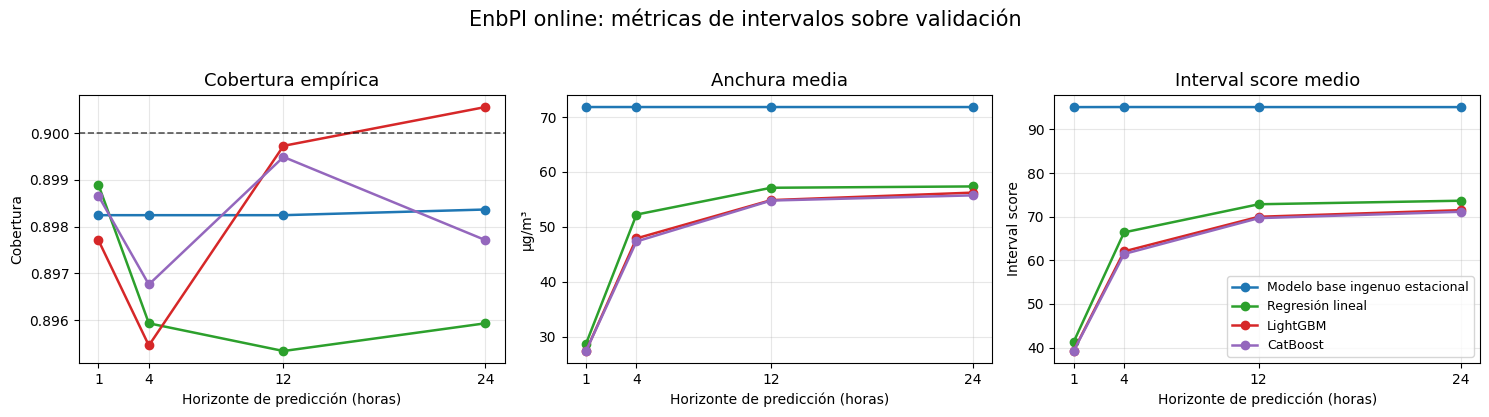

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharex=True)

metric_specs = [
    ("coverage", "Cobertura empírica", "Cobertura"),
    ("mean_width", "Anchura media", "µg/m³"),
    ("mean_interval_score", "Interval score medio", "Interval score"),
]

for ax, (metric_col, title, ylabel) in zip(axes, metric_specs):
    for model_id in MODEL_ORDER:
        model_df = selected_enbpi_metrics_df.loc[selected_enbpi_metrics_df["model"] == model_id].sort_values("horizon")
        ax.plot(
            model_df["horizon"],
            model_df[metric_col],
            marker="o",
            linewidth=1.8,
            color=MODEL_REGISTRY[model_id]["color"],
            label=MODEL_REGISTRY[model_id]["display_name"],
        )

    if metric_col == "coverage":
        ax.axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1.2, color="black", alpha=0.65)

    ax.set_title(title, fontsize=13)
    ax.set_xlabel("Horizonte de predicción (horas)")
    ax.set_ylabel(ylabel)
    ax.set_xticks(HORIZONS)
    ax.grid(True, alpha=0.3)

axes[-1].legend(loc="best", fontsize=9)
fig.suptitle("EnbPI online: métricas de intervalos sobre validación", fontsize=15, y=1.03)
fig.tight_layout()

figure_path = REPORTS_FIGURES_DIR / "fig_enbpi_online_selected_metrics_validation.png"
fig.savefig(figure_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada: {figure_path}")
plt.show()

Figura guardada: c:\trabajo_github\reports\figures\fig_enbpi_coverage_by_block_config_validation.png


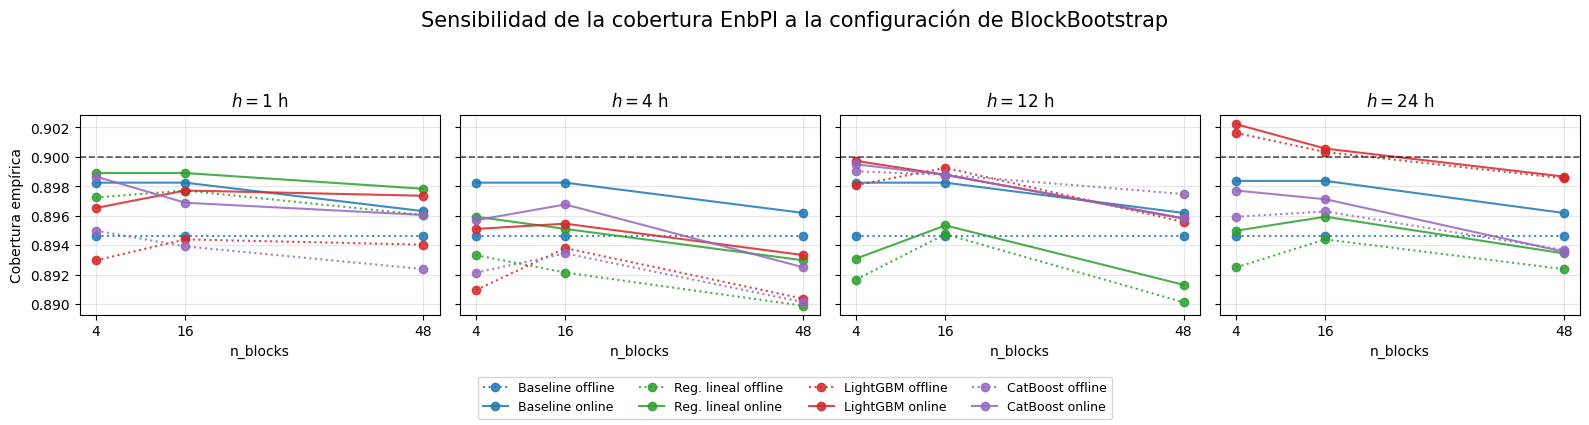

In [13]:
fig, axes = plt.subplots(1, len(HORIZONS), figsize=(16, 4), sharey=True)

if len(HORIZONS) == 1:
    axes = [axes]

for ax, horizon in zip(axes, HORIZONS):
    horizon_df = candidate_metrics_df.loc[
        (candidate_metrics_df["horizon"] == horizon)
        & (candidate_metrics_df["evaluation_mode"].isin([OFFLINE_MODE_NAME, ONLINE_MODE_NAME]))
    ].copy()

    for model_id in MODEL_ORDER:
        model_df = horizon_df.loc[horizon_df["model"] == model_id].copy()
        if model_df.empty:
            continue

        for mode, linestyle in [(OFFLINE_MODE_NAME, ":"), (ONLINE_MODE_NAME, "-")]:
            mode_df = model_df.loc[model_df["evaluation_mode"] == mode].sort_values("n_blocks")
            if mode_df.empty:
                continue
            ax.plot(
                mode_df["n_blocks"],
                mode_df["coverage"],
                marker="o",
                linestyle=linestyle,
                color=MODEL_REGISTRY[model_id]["color"],
                alpha=0.85,
                label=f"{MODEL_REGISTRY[model_id]['short_name']} {mode}",
            )

    ax.axhline(NOMINAL_COVERAGE, linestyle="--", linewidth=1.2, color="black", alpha=0.65)
    ax.set_title(rf"$h={horizon}$ h")
    ax.set_xlabel("n_blocks")
    ax.set_xticks(sorted(candidate_metrics_df["n_blocks"].unique()))
    ax.grid(True, alpha=0.3)

axes[0].set_ylabel("Cobertura empírica")
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, fontsize=9)
fig.suptitle("Sensibilidad de la cobertura EnbPI a la configuración de BlockBootstrap", fontsize=15, y=1.03)
fig.tight_layout(rect=(0, 0.12, 1, 0.95))

coverage_grid_path = REPORTS_FIGURES_DIR / "fig_enbpi_coverage_by_block_config_validation.png"
fig.savefig(coverage_grid_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada: {coverage_grid_path}")
plt.show()

Mejor EnbPI online en h=24 h: CatBoost
Figura guardada: c:\trabajo_github\reports\figures\fig_enbpi_online_example_best_h24.png


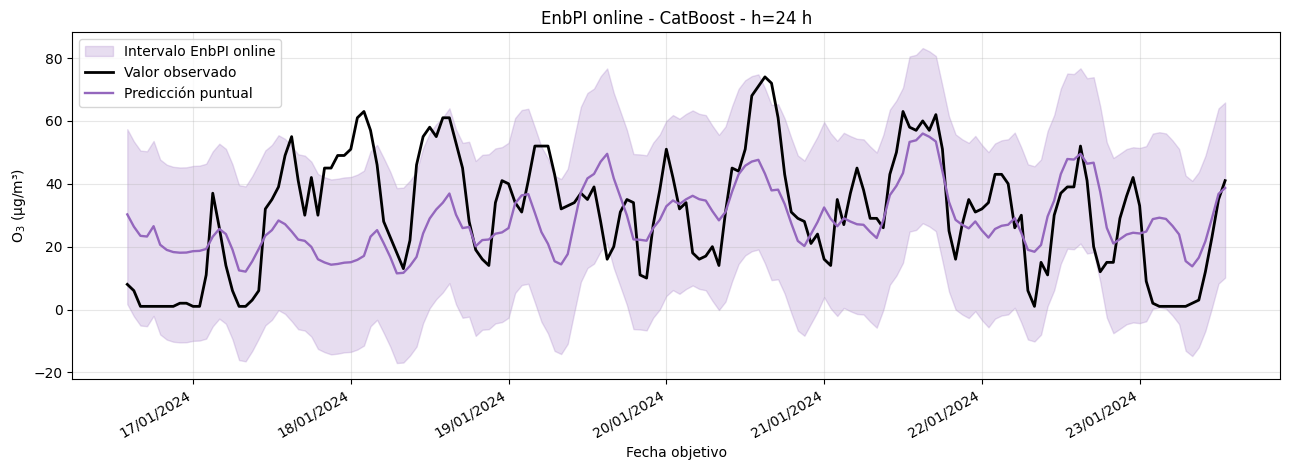

In [14]:
# Figura opcional: ejemplo visual del mejor método EnbPI online en h=24.
EXAMPLE_HORIZON = 24
EXAMPLE_HOURS = 7 * 24

best_example_row = (
    selected_enbpi_metrics_df.loc[selected_enbpi_metrics_df["horizon"] == EXAMPLE_HORIZON]
    .sort_values(["mean_interval_score", "coverage_abs_error", "mean_width"], ascending=[True, True, True])
    .iloc[0]
)

best_model_id = best_example_row["model"]
print(f"Mejor EnbPI online en h={EXAMPLE_HORIZON} h: {MODEL_REGISTRY[best_model_id]['display_name']}")

example_df = selected_enbpi_intervals_df.loc[
    (selected_enbpi_intervals_df["model"] == best_model_id)
    & (selected_enbpi_intervals_df["horizon"] == EXAMPLE_HORIZON)
].copy()
example_df = example_df.sort_values("target_timestamp").reset_index(drop=True)


def select_continuous_block(df: pd.DataFrame, n_hours: int) -> pd.DataFrame:
    df = df.sort_values("target_timestamp").reset_index(drop=True)
    timestamps = pd.DatetimeIndex(df["target_timestamp"])
    available = set(timestamps)

    for start_ts in timestamps:
        expected = pd.date_range(start=start_ts, periods=n_hours, freq="h")
        if all(ts in available for ts in expected):
            return df.loc[df["target_timestamp"].isin(expected)].copy().sort_values("target_timestamp")

    return df.head(n_hours).copy()


example_block = select_continuous_block(example_df, EXAMPLE_HOURS)

fig, ax = plt.subplots(figsize=(13, 4.8))

ax.fill_between(
    example_block["target_timestamp"],
    example_block["lower"],
    example_block["upper"],
    color=MODEL_REGISTRY[best_model_id]["color"],
    alpha=0.22,
    label="Intervalo EnbPI online",
)
ax.plot(
    example_block["target_timestamp"],
    example_block["y_true"],
    color="black",
    linewidth=2.0,
    label="Valor observado",
)
ax.plot(
    example_block["target_timestamp"],
    example_block["y_pred_reference"],
    color=MODEL_REGISTRY[best_model_id]["color"],
    linewidth=1.7,
    label="Predicción puntual",
)

ax.set_title(f"EnbPI online - {MODEL_REGISTRY[best_model_id]['display_name']} - h={EXAMPLE_HORIZON} h")
ax.set_xlabel("Fecha objetivo")
ax.set_ylabel(r"$\mathrm{O}_3$ (µg/m³)")
ax.grid(True, alpha=0.3)
ax.legend(loc="best")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m/%Y"))
fig.autofmt_xdate(rotation=30)
fig.tight_layout()

zoom_path = REPORTS_FIGURES_DIR / f"fig_enbpi_online_example_best_h{EXAMPLE_HORIZON:02d}.png"
fig.savefig(zoom_path, dpi=300, bbox_inches="tight")
print(f"Figura guardada: {zoom_path}")
plt.show()

## 7. Comprobaciones finales

In [15]:
expected_interval_files = [
    REPORTS_INTERVALS_DIR / f"{MODEL_REGISTRY[model_id]['interval_prefix']}_h{horizon:02d}.parquet"
    for model_id in MODEL_ORDER
    for horizon in HORIZONS
]

expected_table_files = [
    candidate_intervals_path,
    selected_intervals_all_path,
    candidate_metrics_path,
    selected_metrics_path,
    selected_metrics_wide_path,
    fit_summary_path,
    saved_paths_path,
]

expected_figure_files = [
    figure_path,
    coverage_grid_path,
    zoom_path,
]

missing_files = [
    path for path in expected_interval_files + expected_table_files + expected_figure_files
    if not path.exists()
]

if missing_files:
    raise FileNotFoundError(f"Faltan archivos esperados: {missing_files}")

if (selected_enbpi_intervals_df["split"] == "test").any():
    raise AssertionError("Se han generado intervalos sobre test, lo que no corresponde en esta fase.")

if selected_enbpi_intervals_df[["lower", "upper", "y_pred_reference"]].isna().any().any():
    raise AssertionError("Existen valores ausentes en predicciones o límites de intervalos.")

if not (selected_enbpi_intervals_df["lower"] <= selected_enbpi_intervals_df["upper"]).all():
    raise AssertionError("Existen intervalos con límite inferior mayor que el superior.")

if len(selected_enbpi_metrics_df) != len(MODEL_ORDER) * len(HORIZONS):
    raise AssertionError("Faltan combinaciones modelo-horizonte en las métricas EnbPI seleccionadas.")

final_check_df = pd.DataFrame(
    {
        "check": [
            "intervalos_seleccionados_guardados",
            "tablas_guardadas",
            "figuras_guardadas",
            "sin_intervalos_test",
            "sin_nan_en_intervalos",
            "limites_ordenados",
            "metricas_completas",
        ],
        "status": ["OK"] * 7,
    }
)

display(final_check_df)
print("Notebook 06c EnbPI finalizado correctamente.")

,check,status
0,intervalos_seleccionados_guardados,OK
1,tablas_guardadas,OK
2,figuras_guardadas,OK
3,sin_intervalos_test,OK
4,sin_nan_en_intervalos,OK
5,limites_ordenados,OK
6,metricas_completas,OK


Notebook 06c EnbPI finalizado correctamente.


## 8. Integración posterior con el notebook 07

Este notebook guarda los intervalos EnbPI online seleccionados con el patrón:

```text
reports/intervals/enbpi_online_<modelo>_hXX.parquet
```

Para compararlos directamente con `split conformal` y CQR en `07_interval_comparison_and_selection.ipynb`, conviene ampliar el registro de métodos de ese notebook para cargar también estos ficheros y distinguir el método mediante la columna `method`.

La selección de configuración se hace sobre validación. Por tanto, si EnbPI entra en la comparación final, el bloque de prueba debería evaluarse en un notebook posterior usando la configuración seleccionada, no reoptimizando sobre `test`.